# 03 — Models: Race Time at 100 % Effort

**Question:** Given an athlete's history of GPS-bearing training runs, what finish time can they expect to achieve at 100 % effort for a target race distance?

We anchor the supervised signal on six known race-day activities and use the remaining ~600 training runs as *pseudo-labels* (each run gives `(distance, moving_time, mean_HR)` — a pace observed at a known fractional effort). All inputs derive from the per-second streams produced by `01_ingest.ipynb`; **`activities.csv` is not used as a model input**, only for race-day filtering and as a diagnostic during 02.

Four ISLR/ESL chapters are exercised:

| Topic | Chapter | Implementation |
|---|---|---|
| Non-linear models | ISLR §3.5 + ch. 7 | Natural cubic splines + `pygam.LinearGAM` |
| Regression trees | ISLR ch. 8 | `RandomForestRegressor`, `GradientBoostingRegressor` |
| Support Vector Machines | ISLR ch. 9 | `SVR(kernel="rbf")` |
| Neural Networks | ESL ch. 11 | PyTorch 1D-CNN over padded per-second streams |

**Validation:** With only six race labels we use **leave-one-race-out** cross-validation; the pseudo-labels (training runs) are shared across folds with race rows held out.


## 3.1 Race Labels

> **ACTION:** fill `RACE_LABELS` below with the six `(distance_km, finish_time_seconds)` tuples. The notebook will fall back to a Riegel-extrapolation baseline if any are missing, but supervised models cannot run without them.


In [77]:
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
assert PROJECT_ROOT.name == "Project"
DATA_DIR = PROJECT_ROOT / "data"

# Fill these in. distance_km is the *official* race distance, finish_time is gun/chip time in seconds.
RACE_LABELS: dict[str, tuple[float, float] | None] = {
    "2023-12-03": (10.0,    2263),   # Köln Nikolauslauf 2023, 37:43
    "2024-04-14": (21.0975, 5093),   # Bonn Half Marathon, 1:34:53 (no HR strap — imputed)
    "2024-07-03": (5.555,   1198),   # Lousberglauf, 19:58
    "2024-10-19": (5.0,     1278),   # DIY-Triathlon run, 21:18
    "2025-06-29": (10.0,    2697),   # Schwarzwald Drachentriathlon run, 44:57
    "2026-04-12": (42.195, 10696),   # Milano Marathon 2026, 2:58:16
}
race_date_strings = list(RACE_LABELS.keys())

all_activities = pd.read_parquet(DATA_DIR / "raw" / "activities_raw.parquet")
all_streams    = pd.read_parquet(DATA_DIR / "streams" / "streams.parquet")

# Restrict to running for the modelling table; cycling/hiking only enter via ATL/CTL/TSB load context.
running_activities = all_activities[all_activities["discipline"] == "running"].copy()
running_streams    = all_streams[all_streams["discipline"] == "running"].copy()
print(f"Running activities: {len(running_activities)}  |  running stream rows: {len(running_streams):,}")


Running activities: 611  |  running stream rows: 1,768,791


## 3.2 Per-Activity Tabular Features (for GAM, Trees, SVR)

We aggregate each running activity into one row. **Every column originates in the per-second streams**, with the single exception of `Relative Effort` and `Perceived Exertion` which are kept aside as targets/diagnostics, *not* features.

| Group | Columns | Origin |
|---|---|---|
| Volume | `distance_km`, `moving_s`, `mean_speed_mps`, `mean_gap_speed_mps` | Streams (sum/mean) |
| HR | `mean_hr`, `p50_hr`, `p90_hr`, `frac_z[1-5]` | Streams |
| Effort proxy | `hr_load = mean_hr × moving_s` | Streams (TRIMP-like) |
| Cadence | `mean_cadence`, `std_cadence` | Streams |
| Calendar | `dow`, `month` | Activity timestamp |
| Banister load (race-day -1) | `atl`, `ctl`, `tsb` | EWMA over daily summed RE (kept for context — RE itself is *not* a feature) |


In [78]:
from tqdm import tqdm

# Infer the athlete's maximum heart rate from observed peaks in running streams.
# The floor at 195 bpm prevents a single noisy spike from setting too low a threshold.
MAX_HEART_RATE = max(int(running_streams["hr_bpm"].dropna().quantile(0.999)), 195)
HR_ZONE_THRESHOLDS = [0, .60, .70, .80, .90, 1.01]   # as fractions of MAX_HEART_RATE

def aggregate_activity_stream(stream_df: pd.DataFrame) -> dict:
    """Collapse one activity's per-second stream into a flat dict of features.

    Also computes a `sample_weight` confidence score (0–1) from four independent
    quality dimensions:
      - gps_coverage:       fraction of seconds with valid GPS speed
      - elevation_coverage: fraction of seconds with valid elevation (needed for GAP)
      - hr_coverage:        fraction of seconds with valid heart rate (drives effort estimate)
      - duration_weight:    full weight at ≥ 30 min moving; ramps linearly below
    Combined as the product of all four. Race rows override this to 1.0 in the
    next cell (they are ground-truth labels regardless of sensor quality).
    """
    total_seconds = len(stream_df)
    is_moving     = stream_df["speed_mps"] > 0.5
    heart_rate    = stream_df["hr_bpm"].dropna()

    features_dict = {
        # Prefer Strava's cumulative distance; fall back to ∫ speed dt for streams
        # that lack dist_m (e.g. phone-recorded races without an HR strap).
        "distance_km":        (stream_df["dist_m"].max() / 1000.0
                                if stream_df["dist_m"].notna().any() and stream_df["dist_m"].max() > 0
                                else float(stream_df["speed_mps"].fillna(0).sum()) / 1000.0),
        "moving_s":           int(is_moving.sum()),
        "mean_speed_mps":     stream_df.loc[is_moving, "speed_mps"].mean(),
        "mean_gap_speed_mps": stream_df.loc[is_moving, "gap_speed_mps"].mean(),
        "mean_hr":            heart_rate.mean()         if len(heart_rate) else np.nan,
        "p50_hr":             heart_rate.median()       if len(heart_rate) else np.nan,
        "p90_hr":             heart_rate.quantile(0.9)  if len(heart_rate) else np.nan,
        "mean_cadence":       stream_df["cadence_rpm"].mean(),
        "std_cadence":        stream_df["cadence_rpm"].std(),
    }
    # HR zone fractions: fraction of moving seconds spent in each of 5 HR zones.
    # All five keys are always present; NaN when HR data is missing so imputation can fill them.
    zone_labels = [f"frac_z{i}" for i in range(1, 6)]
    if len(heart_rate):
        zones = pd.cut(heart_rate / MAX_HEART_RATE, bins=HR_ZONE_THRESHOLDS, labels=zone_labels)
        for zone, fraction in zones.value_counts(normalize=True).reindex(zone_labels, fill_value=0).items():
            features_dict[zone] = float(fraction)
    else:
        for zone in zone_labels:
            features_dict[zone] = np.nan

    # hr_load: a TRIMP-like scalar (mean HR × moving minutes). NaN when HR is missing.
    features_dict["hr_load"] = (
        features_dict["mean_hr"] * features_dict["moving_s"] / 60.0
        if pd.notna(features_dict["mean_hr"]) else np.nan
    )

    # Confidence score: product of four coverage dimensions (0 = unusable, 1 = perfect).
    gps_coverage       = float(stream_df["speed_mps"].notna().sum()) / total_seconds if total_seconds > 0 else 0.0
    elevation_coverage = float(stream_df["ele_m"].notna().sum())     / total_seconds if total_seconds > 0 else 0.0
    hr_coverage        = float(stream_df["hr_bpm"].notna().sum())    / total_seconds if total_seconds > 0 else 0.0
    duration_weight    = min(1.0, features_dict["moving_s"] / 1800.0)   # full weight at ≥ 30 min

    features_dict["conf_gps"] = gps_coverage
    features_dict["conf_ele"] = elevation_coverage
    features_dict["conf_hr"]  = hr_coverage
    features_dict["conf_dur"] = duration_weight
    features_dict["sample_weight"] = gps_coverage * elevation_coverage * hr_coverage * duration_weight
    return features_dict

# Aggregate each activity's stream into one feature row.
aggregated_rows = []
for activity_id, activity_stream in tqdm(running_streams.groupby("activity_id"), desc="Aggregating stream features"):
    aggregated_rows.append({"activity_id": activity_id, **aggregate_activity_stream(activity_stream)})
stream_aggregates = pd.DataFrame(aggregated_rows)

features = running_activities[["activity_id", "activity_dt", "Relative Effort", "Perceived Exertion"]].merge(
    stream_aggregates, on="activity_id")
features["dow"]   = features["activity_dt"].dt.dayofweek
features["month"] = features["activity_dt"].dt.month

# Banister training load: ATL (Acute Training Load, 7-day EWMA = "fatigue"),
# CTL (Chronic Training Load, 42-day EWMA = "fitness"), TSB = CTL - ATL ("form").
# Shifted by 1 day so each activity only sees load from *before* that activity (no lookahead).
features["activity_date"] = features["activity_dt"].dt.tz_convert("UTC").dt.floor("D")
daily_load = (
    features.groupby("activity_date")["Relative Effort"].sum()
            .reindex(pd.date_range(features["activity_date"].min(),
                                   features["activity_date"].max(), freq="D", tz="UTC"))
            .fillna(0)
)
acute_load              = daily_load.ewm(halflife=7).mean().shift(1);  acute_load.name = "atl"
chronic_load            = daily_load.ewm(halflife=42).mean().shift(1); chronic_load.name = "ctl"
training_stress_balance = (chronic_load - acute_load).rename("tsb")
features = features.merge(
    pd.concat([acute_load, chronic_load, training_stress_balance], axis=1),
    left_on="activity_date", right_index=True
)

# Drop activities with no GPS distance or no moving time — these cannot be pseudo-labels.
features = features.dropna(subset=["distance_km", "moving_s"]).reset_index(drop=True)
n_missing_hr = int(features["mean_hr"].isna().sum())
print(f"Per-activity feature table (before HR imputation): {features.shape}")
print(f"  Activities missing heart rate (race rows will be imputed): {n_missing_hr}")
print(f"\nSample-weight distribution (before race-row override):")
print(features["sample_weight"].describe().round(3))


Aggregating stream features: 100%|██████████| 605/605 [00:00<00:00, 898.63it/s] 

Per-activity feature table (before HR imputation): (605, 30)
  Activities missing heart rate (race rows will be imputed): 110

Sample-weight distribution (before race-row override):
count    605.000
mean       0.579
std        0.420
min        0.000
25%        0.139
50%        0.704
75%        1.000
max        1.000
Name: sample_weight, dtype: float64


## 3.3 Target & Pseudo-Labels

- **Hard target** (n=6): observed finish time at each race date.
- **Pseudo-labels** (n≈600): every training run yields `(pace = distance / moving_s, effort = mean_hr / HRMAX)`.
  We learn the **pace-vs-effort surface** from these and *invert* it at `effort = 1.00` to predict 100 %-effort race pace.

This is the bridge that turns six labels into a useful supervised problem. It is also the place where a non-CS reader will reasonably be confused, so be explicit:

> *We are not predicting any single race directly. We are learning the curve **"how fast does this athlete go at effort X?"** from hundreds of runs, then asking the curve **"and at effort X = 1.00, over 42.195 km, in their fitness state on race day?"***


HR imputed for race 2024-04-14 (source FIT had no heart-rate sensor data)
Dropped 109 non-race training activities with no heart rate data.

Final feature table: (496, 36)
Race rows: 6 of 6 expected


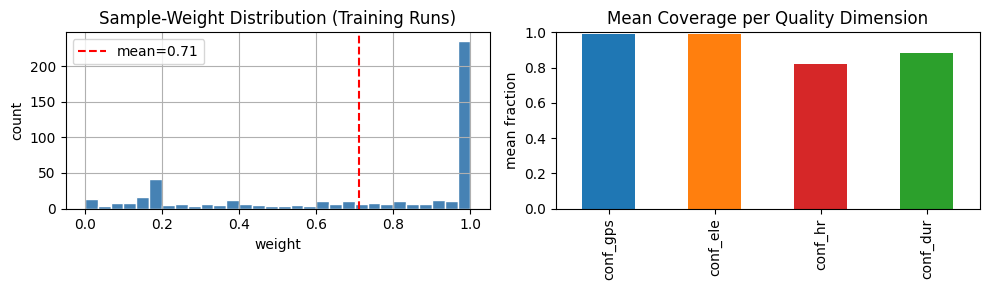

In [79]:
RACE_DISTANCE_KM = 5.555   # target race distance for the inference section (§3.9)

# Pace (seconds per km) and fractional effort for each activity.
# Effort = mean HR / MAX_HEART_RATE; for race rows it is overridden to 1.00 below.
features["pace_s_per_km"] = features["moving_s"] / features["distance_km"]
features["effort"]        = features["mean_hr"] / MAX_HEART_RATE

# Remove activities with near-zero GPS distance (they produce infinite pace and crash the models).
n_infinite_pace = int((~np.isfinite(features["pace_s_per_km"])).sum())
if n_infinite_pace:
    print(f"Dropping {n_infinite_pace} activities with non-finite pace (GPS distance ≈ 0).")
features = features[np.isfinite(features["pace_s_per_km"])].reset_index(drop=True)

# ── Race-row identification ────────────────────────────────────────────────────
# Match by date string (YYYY-MM-DD in UTC) rather than timestamp to avoid any
# precision or timezone-representation issues between the parquet and RACE_LABELS.
activity_date_utc_str = features["activity_dt"].dt.tz_convert("UTC").dt.strftime("%Y-%m-%d")
features["is_race"]   = activity_date_utc_str.isin(race_date_strings)
features["race_date"] = activity_date_utc_str.where(features["is_race"])

missing_race_dates = [d for d in race_date_strings
                      if d not in features.loc[features["is_race"], "race_date"].values]
if missing_race_dates:
    print(f"WARNING: race dates not found in feature table: {missing_race_dates}")
    print("  Check that the activity was exported by Strava and is in the streams parquet.")

# ── HR imputation for races recorded without an HR strap ─────────────────────
# The 2024-04-14 Bonn Half Marathon has no heart-rate data. We impute its HR
# features from the median of the 28 days preceding the race so it can be
# included as the 6th LORO fold. This is the only manual exception in the pipeline.
HR_FEATURE_COLUMNS = [
    "mean_hr", "p50_hr", "p90_hr",
    "frac_z1", "frac_z2", "frac_z3", "frac_z4", "frac_z5",
    "hr_load",
]

def impute_hr_features(all_features: pd.DataFrame, race_date_utc: pd.Timestamp) -> dict:
    """Return median HR features from the 28 days before the race date.

    Widens to all prior activities if the 28-day window contains no HR data
    (edge case for the very first race in the dataset).
    """
    recent_window = all_features[
        (all_features["activity_dt"] >= race_date_utc - pd.Timedelta(days=28)) &
        (all_features["activity_dt"] <  race_date_utc) &
        all_features["mean_hr"].notna()
    ]
    if len(recent_window) == 0:
        recent_window = all_features[
            (all_features["activity_dt"] < race_date_utc) &
            all_features["mean_hr"].notna()
        ]
    if len(recent_window) == 0:
        return {}
    return recent_window[HR_FEATURE_COLUMNS].median(numeric_only=True).to_dict()

for row_index in features.index[features["is_race"]].tolist():
    if pd.isna(features.loc[row_index, "mean_hr"]):
        race_date_utc = pd.Timestamp(features.loc[row_index, "race_date"], tz="UTC")
        imputed_values = impute_hr_features(features, race_date_utc)
        if imputed_values:
            for column, value in imputed_values.items():
                if pd.notna(value):
                    features.loc[row_index, column] = value
            features.loc[row_index, "effort"] = features.loc[row_index, "mean_hr"] / MAX_HEART_RATE
            print(f"HR imputed for race {features.loc[row_index, 'race_date']} "
                  f"(source FIT had no heart-rate sensor data)")
        else:
            print(f"WARNING: could not impute HR for {features.loc[row_index, 'race_date']} "
                  f"— no prior activities found")

# Race rows: effort is 1.00 by definition (races are 100 %-effort observations).
features.loc[features["is_race"], "effort"]        = 1.00
# Race rows: sample weight = 1.0 regardless of sensor coverage (ground-truth labels).
features.loc[features["is_race"], "sample_weight"] = 1.0

# Drop non-race activities that still have no HR after imputation (effort cannot be estimated).
# Race rows are NEVER dropped here — if HR imputation failed, the row is retained with a warning.
rows_to_drop = features["mean_hr"].isna() & ~features["is_race"]
n_dropped = int(rows_to_drop.sum())
features = features[~rows_to_drop].reset_index(drop=True)
if n_dropped:
    print(f"Dropped {n_dropped} non-race training activities with no heart rate data.")

# Attach known finish times to the race rows for use in the LORO summary below.
race_finish_times = pd.DataFrame(
    [(date, *label) if label else (date, np.nan, np.nan) for date, label in RACE_LABELS.items()],
    columns=["race_date", "race_distance_km", "race_finish_s"]
)
features = features.merge(race_finish_times, on="race_date", how="left")

print(f"\nFinal feature table: {features.shape}")
print(f"Race rows: {int(features['is_race'].sum())} of {len(RACE_LABELS)} expected")

import matplotlib.pyplot as plt
training_weights = features.loc[~features["is_race"], "sample_weight"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
training_weights.hist(bins=30, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Sample-Weight Distribution (Training Runs)")
axes[0].set_xlabel("weight"); axes[0].set_ylabel("count")
axes[0].axvline(training_weights.mean(), color="red", ls="--",
                label=f"mean={training_weights.mean():.2f}")
axes[0].legend()
features.loc[~features["is_race"], ["conf_gps", "conf_ele", "conf_hr", "conf_dur"]].mean().plot.bar(
    ax=axes[1], color=["tab:blue", "tab:orange", "tab:red", "tab:green"])
axes[1].set_title("Mean Coverage per Quality Dimension")
axes[1].set_ylabel("mean fraction"); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()


## 3.4 Feature Matrix and Leave-One-Race-Out CV Split

`X` is the per-activity feature matrix; `y` is `pace_s_per_km`. **Race rows form the held-out folds, one at a time.**

The same `X` is used by GAM / Trees / SVR. The NN takes a different representation (per-second tensors) — see §3.8.


In [80]:
FEATURE_COLUMNS = [
    "distance_km", "moving_s", "mean_speed_mps", "mean_gap_speed_mps",
    "mean_hr", "p50_hr", "p90_hr",
    "frac_z1", "frac_z2", "frac_z3", "frac_z4", "frac_z5",
    "hr_load", "mean_cadence", "std_cadence",
    "atl", "ctl", "tsb",          # Banister load: ATL = acute load, CTL = chronic load, TSB = form
    "effort",
    "dow", "month",
]
feature_matrix   = features[FEATURE_COLUMNS].astype("float64").fillna(
    features[FEATURE_COLUMNS].median(numeric_only=True))
target_pace      = features["pace_s_per_km"].astype("float64")   # seconds per km
activity_weights = features["sample_weight"].astype("float64")   # confidence weight per activity

race_row_indices = features.index[features["is_race"]].tolist()

def leave_one_race_out_folds():
    """Generate LORO cross-validation folds with temporal honesty.

    Each fold holds out one race and trains only on activities recorded
    *strictly before* that race date — no data from the future leaks in.

    Yields
    ------
    train_indices : list[int]    row indices into `features` / `feature_matrix`
    test_index    : list[int]    single-element list with the held-out race row
    held_out_date : pd.Timestamp UTC midnight of the held-out race
    """
    for race_row_idx in race_row_indices:
        held_out_date = pd.Timestamp(features.loc[race_row_idx, "race_date"], tz="UTC")
        train_indices = [
            j for j in features.index
            if j != race_row_idx
            and not features.loc[j, "is_race"]
            and features.loc[j, "activity_dt"] < held_out_date
        ]
        yield train_indices, [race_row_idx], held_out_date

print(f"Feature matrix: {feature_matrix.shape}  |  Race rows: {len(race_row_indices)}")
for train_indices, test_index, held_out_date in leave_one_race_out_folds():
    fold_weights = activity_weights.iloc[train_indices]
    print(f"  Fold {held_out_date.strftime('%Y-%m-%d')}:  "
          f"train_n={len(train_indices)}  "
          f"mean_weight={fold_weights.mean():.3f}  "
          f"min_weight={fold_weights.min():.3f}")


Feature matrix: (496, 21)  |  Race rows: 6
  Fold 2023-12-03:  train_n=247  mean_weight=0.672  min_weight=0.001
  Fold 2024-04-14:  train_n=268  mean_weight=0.633  min_weight=0.001
  Fold 2024-07-03:  train_n=286  mean_weight=0.603  min_weight=0.001
  Fold 2024-10-19:  train_n=300  mean_weight=0.585  min_weight=0.000
  Fold 2025-06-29:  train_n=341  mean_weight=0.605  min_weight=0.000
  Fold 2026-04-12:  train_n=490  mean_weight=0.711  min_weight=0.000


### Temporal Honesty

All race-pace predictions in this notebook are produced by fitting on activities **strictly before the target race date**. This matches what Riegel-style calculators and Strava's own race predictor have access to at race time, so the per-race errors in the LORO summary are directly interpretable as *"how well could this predictor have done on race day, with no future data?"*.

Concretely, every fold of `loro_folds()` above yields a training set of only those activities with `activity_dt < race_day`. The earliest race (2023-12-03) therefore trains on a much smaller history than the marathon (2026-04-12); we report `train_n` per fold so this asymmetry is visible.

The same rule generalises to ad-hoc queries: `predict_pace_for_date(date, distance_km)` (defined in 3.9) re-fits each tabular model on the slice of `feat` strictly before the supplied date — so asking "what could I race a 10K at *today*?" uses only activities up to yesterday.


## 3.5 Model A — Splines + GAM

`pygam.LinearGAM` with smooth terms on the four most informative features, factor terms on calendar columns, lambda picked by `gridsearch`.


In [81]:
from pygam import LinearGAM, s, f

# GAM uses smooth spline terms on continuous features and factor terms on calendar variables.
smooth_feature_names = ["distance_km", "mean_hr", "mean_gap_speed_mps", "tsb"]
factor_feature_names = ["dow", "month"]
gam_feature_columns  = smooth_feature_names + factor_feature_names

def fit_gam_model(train_features: pd.DataFrame, train_pace: pd.Series,
                  train_weights: pd.Series | None = None) -> LinearGAM:
    """Fit a LinearGAM with smooth + factor terms; lambda picked by grid search."""
    X_gam      = train_features[gam_feature_columns].values
    gam_terms  = s(0) + s(1) + s(2) + s(3) + f(4) + f(5)
    weights    = train_weights.values if train_weights is not None else None
    return LinearGAM(gam_terms).gridsearch(
        X_gam, train_pace.values, weights=weights,
        lam=np.logspace(-2, 2, 9), progress=False
    )

# Diagnostic fit on the full table (for summary only — LORO fits use weighted subsets).
gam_model = fit_gam_model(feature_matrix, target_pace, activity_weights)
gam_model.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      33.096
Link Function:                     IdentityLink Log Likelihood:                                  -2441.878
Number of Samples:                          496 AIC:                                             4951.9481
                                                AICc:                                            4957.1406
                                                GCV:                                              446.4991
                                                Scale:                                             19.8296
                                                Pseudo R-Squared:                                    0.813
Feature Function                  Lam

/var/folders/q9/d95wjtz97h5dptsf6gjsbvdc0000gn/T/ipykernel_95075/336154849.py:21: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_model.summary()


## 3.6 Model B — Trees / Boosting

Random Forest and Gradient Boosting share the same feature matrix as GAM. We report feature importance and use boosting's quantile heads to construct a 90 % prediction interval.


In [82]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def fit_tree_models(train_features: pd.DataFrame, train_pace: pd.Series,
                    train_weights: pd.Series | None = None) -> dict:
    """Fit Random Forest + Gradient Boosting (point estimate + lower/upper quantiles)."""
    weights = train_weights.values if train_weights is not None else None
    return {
        "RF":     RandomForestRegressor(n_estimators=400, min_samples_leaf=4, random_state=0)
                  .fit(train_features, train_pace, sample_weight=weights),
        "GBR":    GradientBoostingRegressor(loss="squared_error", n_estimators=300, max_depth=3, random_state=0)
                  .fit(train_features, train_pace, sample_weight=weights),
        "GBR_lo": GradientBoostingRegressor(loss="quantile", alpha=0.05, n_estimators=300, max_depth=3, random_state=0)
                  .fit(train_features, train_pace, sample_weight=weights),
        "GBR_hi": GradientBoostingRegressor(loss="quantile", alpha=0.95, n_estimators=300, max_depth=3, random_state=0)
                  .fit(train_features, train_pace, sample_weight=weights),
    }

# Diagnostic fit on the full table (for feature importance only — not used in predictions).
tree_models = fit_tree_models(feature_matrix, target_pace, activity_weights)
random_forest, gradient_boosting = tree_models["RF"], tree_models["GBR"]

feature_importance = pd.Series(
    random_forest.feature_importances_, index=FEATURE_COLUMNS
).sort_values(ascending=False)
print(feature_importance.head(10))


mean_speed_mps        0.875433
moving_s              0.018974
mean_gap_speed_mps    0.016606
mean_cadence          0.014864
frac_z1               0.008841
frac_z2               0.007737
p50_hr                0.006453
effort                0.006104
std_cadence           0.005590
hr_load               0.005209
dtype: float64


## 3.7 Model C — SVR

RBF-kernel SVR inside a `StandardScaler` pipeline. Grid search on `(C, gamma, epsilon)` is intentionally coarse — with ~600 rows the model is fast.


In [83]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, KFold

SVR_HYPERPARAMETER_GRID = {
    "svr__C":       [1, 10, 100],
    "svr__gamma":   ["scale", 0.01, 0.1],
    "svr__epsilon": [1, 5, 10],
}

def fit_svr_model(train_features: pd.DataFrame, train_pace: pd.Series,
                  train_weights: pd.Series | None = None) -> Pipeline:
    """Fit an RBF-kernel SVR inside a StandardScaler pipeline with grid-searched hyperparameters."""
    svr_pipeline = Pipeline([("scaler", StandardScaler()), ("svr", SVR(kernel="rbf"))])
    cross_validator = KFold(min(5, max(2, len(train_features) // 50)), shuffle=True, random_state=0)
    grid_search = GridSearchCV(svr_pipeline, SVR_HYPERPARAMETER_GRID, cv=cross_validator, n_jobs=-1)
    fit_kwargs = {"svr__sample_weight": train_weights.values} if train_weights is not None else {}
    grid_search.fit(train_features, train_pace, **fit_kwargs)
    return grid_search.best_estimator_

# Diagnostic fit on the full table.
svr_model = fit_svr_model(feature_matrix, target_pace, activity_weights)
print("Best SVR hyperparameters:", {
    k: v for k, v in svr_model.named_steps["svr"].get_params().items()
    if k in ("C", "gamma", "epsilon")
})


Best SVR hyperparameters: {'C': 100, 'epsilon': 1, 'gamma': 0.01}


In [84]:
def fit_all_tabular_models(train_features: pd.DataFrame, train_pace: pd.Series,
                           train_weights: pd.Series | None = None) -> dict:
    """Fit GAM, Random Forest, Gradient Boosting (+ quantile variants), and SVR in one call."""
    tree_dict = fit_tree_models(train_features, train_pace, train_weights)
    return {
        "GAM":    fit_gam_model(train_features, train_pace, train_weights),
        "RF":     tree_dict["RF"],
        "GBR":    tree_dict["GBR"],
        "GBR_lo": tree_dict["GBR_lo"],
        "GBR_hi": tree_dict["GBR_hi"],
        "SVR":    fit_svr_model(train_features, train_pace, train_weights),
    }

def predict_pace_with_model(model, model_name: str, inference_row: pd.DataFrame,
                             train_features: pd.DataFrame = None) -> float:
    """Return predicted pace (s/km) for a single inference row, NaN-safe."""
    if model_name == "GAM":
        return float(model.predict(inference_row[gam_feature_columns].fillna(0).values)[0])
    reference_features = train_features if train_features is not None else feature_matrix
    return float(model.predict(
        inference_row.fillna(reference_features.median(numeric_only=True))
    )[0])


## 3.8 Model D — Neural Network (1D-CNN over per-second streams)

The first three models throw away time order — they collapse each run to summary statistics. The NN keeps the per-second sequence: at time `t` an activity is described by a vector of `(gap_speed, hr, cadence, grade)`. A 1D-CNN slides learnable filters along the time axis, picking up local patterns (e.g. a sustained tempo block, an interval set) that summary stats can't see.

### Architecture

```
input  (B, 4, T)            channels = [gap_speed, hr, cadence, grade]
  Conv1d(4 → 32, k=7) → BN → ReLU → MaxPool(4)
  Conv1d(32 → 64, k=5) → BN → ReLU → MaxPool(4)
  Conv1d(64 → 128, k=3) → BN → ReLU → AdaptiveAvgPool1d(1)
  Flatten → Dropout(0.3) → Linear(128 → 64) → ReLU → Linear(64 → 1)
output (B, 1)               predicted pace (s/km)
```

### Training Recipe

1. **Resample to 1 Hz** on a uniform grid (some FIT files emit at 2 Hz / variable-rate). Standardise each channel using training-set statistics only.
2. **Pad** to a fixed length `T_max` (e.g. 95th percentile of duration in seconds, ≈ 7200) with `0` and a binary mask channel — or use `pack_padded_sequence` if you swap the CNN backbone for an LSTM.
3. **Loss** = `MSELoss` on `log(pace_s_per_km)` (log-target tames long-tail variance).
4. **Optimiser** = `AdamW(lr=1e-3, weight_decay=1e-4)`, **scheduler** = `CosineAnnealingLR`.
5. **Batch size** 32, **early stopping** on validation MAE with patience 10.
6. **Validation** = leave-one-race-out, same as the tabular models. The race row is dropped from the training set in each fold and predicted at the end.
7. **What to monitor:** training/validation loss curves; predicted-vs-actual scatter on validation; for race-day prediction, the gradient-norm of the input channels (a sanity check that the model is using HR and GAP, not just distance).
8. **Swap to LSTM:** replace the Conv1d stack with `nn.LSTM(input_size=4, hidden_size=64, num_layers=2, batch_first=True, dropout=0.3)` and take the final hidden state. Everything else (loss, schedule, validation) stays identical.

The cell below scaffolds the data tensors, model, and a one-fold training loop. Set `RUN_NN = True` to actually train (requires `torch`).


In [85]:
RUN_NN = False           # flip to True to train the 1D-CNN (requires `torch`)
EPOCHS_PER_FOLD = 30

if RUN_NN:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset

    STREAM_CHANNELS = ["gap_speed_mps", "hr_bpm", "cadence_rpm", "ele_m"]
    SEQUENCE_LENGTH = 7200   # pad/truncate each activity to this many seconds

    def activity_stream_to_tensor(activity_stream: pd.DataFrame) -> np.ndarray:
        """Convert one activity's per-second stream to a (4, SEQUENCE_LENGTH) numpy array.

        Channel order: [grade-adjusted speed, heart rate, cadence, grade].
        Elevation is replaced by per-second gradient (grade = Δele / Δdist, clipped to ±0.45).
        Missing values are zeroed. Output is transposed to (channels, time).
        """
        step_dist = activity_stream.sort_values("elapsed_s")["dist_m"].diff().fillna(0).to_numpy()
        stream_2d = (activity_stream.set_index("elapsed_s").sort_index()[STREAM_CHANNELS]
                                    .astype("float32").interpolate(limit_direction="both").to_numpy(copy=True))
        stream_2d[np.isnan(stream_2d)] = 0.0
        elevation = stream_2d[:, 3].copy()
        grade     = np.zeros_like(elevation)
        has_dist  = step_dist > 0.1
        grade[has_dist] = np.clip(np.gradient(elevation)[has_dist] / step_dist[has_dist], -0.45, 0.45)
        stream_2d[:, 3] = grade
        if stream_2d.shape[0] >= SEQUENCE_LENGTH:
            stream_2d = stream_2d[:SEQUENCE_LENGTH]
        else:
            stream_2d = np.pad(stream_2d, ((0, SEQUENCE_LENGTH - stream_2d.shape[0]), (0, 0)),
                               constant_values=0)
        return stream_2d.T   # (channels, time)

    tensor_list, pace_targets, kept_row_indices, kept_datetimes, kept_weights = [], [], [], [], []
    for feature_row_idx, activity_id in enumerate(features["activity_id"].tolist()):
        activity_stream = running_streams[running_streams["activity_id"] == activity_id]
        if len(activity_stream) < 60:
            continue
        tensor_list.append(activity_stream_to_tensor(activity_stream))
        pace_targets.append(float(np.log(features.loc[feature_row_idx, "pace_s_per_km"])))
        kept_row_indices.append(feature_row_idx)
        kept_datetimes.append(features.loc[feature_row_idx, "activity_dt"])
        kept_weights.append(float(features.loc[feature_row_idx, "sample_weight"]))

    stream_tensors      = torch.tensor(np.stack(tensor_list), dtype=torch.float32)
    log_pace_targets    = torch.tensor(pace_targets,          dtype=torch.float32)
    weight_tensor       = torch.tensor(kept_weights,          dtype=torch.float32)
    kept_indices_array  = np.array(kept_row_indices)
    kept_datetime_array = pd.to_datetime(kept_datetimes, utc=True)
    print(f"Tensor dataset: {stream_tensors.shape}  log-pace targets: {log_pace_targets.shape}")

    class OneDimensionalCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.network = nn.Sequential(
                nn.Conv1d(4, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),
                nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),
                nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
                nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1),
            )
        def forward(self, x):
            return self.network(x).squeeze(-1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def train_one_fold(train_local_indices: np.ndarray, test_local_index: int) -> float:
        """Train the CNN on one LORO fold and return the predicted log-pace for the held-out race."""
        model     = OneDimensionalCNN().to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PER_FOLD)
        X_train = stream_tensors[train_local_indices].to(device)
        y_train = log_pace_targets[train_local_indices].to(device)
        w_train = weight_tensor[train_local_indices].to(device)
        X_test  = stream_tensors[test_local_index:test_local_index + 1].to(device)
        loader  = DataLoader(TensorDataset(X_train, y_train, w_train), batch_size=32, shuffle=True)
        for _ in range(EPOCHS_PER_FOLD):
            model.train()
            for X_batch, y_batch, w_batch in loader:
                optimizer.zero_grad()
                loss = ((model(X_batch) - y_batch) ** 2 * w_batch).mean()
                loss.backward()
                optimizer.step()
            scheduler.step()
        model.eval()
        with torch.no_grad():
            return float(model(X_test).item())

    nn_loro_predictions = {}
    for train_indices, test_index, held_out_date in leave_one_race_out_folds():
        if test_index[0] not in kept_indices_array:
            print(f"Skipping {held_out_date:%Y-%m-%d}: race activity has fewer than 60 stream rows.")
            continue
        train_local = np.where(
            np.isin(kept_indices_array, train_indices) & (kept_datetime_array < held_out_date)
        )[0]
        test_local  = int(np.where(kept_indices_array == test_index[0])[0][0])
        predicted_log_pace = train_one_fold(train_local, test_local)
        predicted_pace     = float(np.exp(predicted_log_pace))
        nn_loro_predictions[held_out_date.strftime("%Y-%m-%d")] = predicted_pace
        print(f"  CNN fold {held_out_date:%Y-%m-%d}: train_n={len(train_local)}"
              f"  predicted_pace={predicted_pace:.1f} s/km")
else:
    nn_loro_predictions = {}
    print("RUN_NN = False — set to True and run cell again to train the 1D-CNN.")


RUN_NN = False — set to True and run cell again to train the 1D-CNN.


## 3.9 Race-Time Inference at 100 % Effort

For each tabular model we construct a single inference row representing **the target race** at the chosen distance, effort = 1.00, fitness state = race-day Banister load, calendar = race day, all stream-derived features = the median over the athlete's last four weeks of running. The predicted *pace* (s/km) × 42.195 gives finish time in seconds.

We also report a **Riegel baseline** as a sanity check: `finish_time = best_shorter_race_time × (RACE_DISTANCE_KM / shorter_race_km) ^ 1.06` (Riegel 1977). If a model's prediction is wildly off Riegel, it is probably extrapolating outside its training support.


In [86]:
def fmt_hms(total_seconds: float) -> str:
    """Format seconds as h:mm:ss."""
    s = int(total_seconds)
    return f"{s // 3600:d}:{(s % 3600) // 60:02d}:{s % 60:02d}"

def riegel_prediction(reference_time_s: float, reference_dist_km: float,
                       target_dist_km: float = RACE_DISTANCE_KM) -> float:
    """Riegel 1977 formula: finish_time = best_time × (target_dist / best_dist) ^ 1.06."""
    return reference_time_s * (target_dist_km / reference_dist_km) ** 1.06

def build_inference_row(race_date_str: str, target_dist_km: float = RACE_DISTANCE_KM) -> pd.DataFrame:
    """Build a one-row inference frame for the given race date.

    Uses the race-day Banister load (ATL/CTL/TSB) and median values from the
    4 weeks before the race for all other features. Effort is set to 1.00 (100 %).
    """
    race_timestamp  = pd.Timestamp(race_date_str, tz="UTC")
    recent_training = features[
        (features["activity_dt"] >= race_timestamp - pd.Timedelta(days=28)) &
        (features["activity_dt"] <  race_timestamp)
    ]
    base = recent_training[FEATURE_COLUMNS].median(numeric_only=True).to_dict()
    base["distance_km"] = target_dist_km
    base["effort"]      = 1.00
    base["dow"]         = race_timestamp.dayofweek
    base["month"]       = race_timestamp.month
    race_row = features[features["race_date"] == race_date_str]
    if len(race_row):
        for banister_col in ("atl", "ctl", "tsb"):
            base[banister_col] = float(race_row.iloc[0][banister_col])
    return pd.DataFrame([base])[FEATURE_COLUMNS]

def predict_race_pace_for_date(target_date_str: str,
                                target_dist_km: float = RACE_DISTANCE_KM) -> dict:
    """Fit all tabular models on activities before target_date and predict race pace at effort=1.0."""
    target_timestamp = pd.Timestamp(target_date_str, tz="UTC")
    prior_training   = features.index[
        (features["activity_dt"] < target_timestamp) & ~features["is_race"]
    ].tolist()
    if not prior_training:
        print(f"Warning: no training data before {target_date_str}")
        return {}
    train_features = feature_matrix.loc[prior_training]
    train_pace     = target_pace.loc[prior_training]
    train_weights  = activity_weights.loc[prior_training]
    fitted_models  = fit_all_tabular_models(train_features, train_pace, train_weights)
    inference_row  = build_inference_row(target_date_str, target_dist_km)
    return {name: predict_pace_with_model(model, name, inference_row, train_features)
            for name, model in fitted_models.items()}

# ── Leave-One-Race-Out Summary ────────────────────────────────────────────────
print("\n" + "=" * 80)
print("LEAVE-ONE-RACE-OUT SUMMARY (temporally honest, confidence-weighted fits)")
print("=" * 80)

loro_results = []
for train_indices, test_index, held_out_date in leave_one_race_out_folds():
    held_out_race          = features.iloc[test_index[0]]
    held_out_date_str      = held_out_race["race_date"]
    observed_distance_km   = held_out_race["race_distance_km"]
    observed_finish_time_s = held_out_race["race_finish_s"]

    if pd.isna(observed_finish_time_s):
        print(f"Skipping {held_out_date_str}: no finish time in RACE_LABELS")
        continue

    train_features = feature_matrix.iloc[train_indices]
    train_pace_    = target_pace.iloc[train_indices]
    train_weights_ = activity_weights.iloc[train_indices]
    fitted_models  = fit_all_tabular_models(train_features, train_pace_, train_weights_)
    inference_row  = build_inference_row(held_out_date_str, observed_distance_km)

    result_row = {
        "race_date":      held_out_date_str,
        "distance_km":    observed_distance_km,
        "observed_time_s": observed_finish_time_s,
    }
    for model_name, model in fitted_models.items():
        predicted_pace     = predict_pace_with_model(model, model_name, inference_row, train_features)
        predicted_finish_s = predicted_pace * observed_distance_km
        result_row[f"{model_name}_pace"]    = predicted_pace
        result_row[f"{model_name}_time"]    = predicted_finish_s
        result_row[f"{model_name}_err_s"]   = predicted_finish_s - observed_finish_time_s
        result_row[f"{model_name}_err_pct"] = 100 * (predicted_finish_s - observed_finish_time_s) / observed_finish_time_s

    # Riegel baseline: use the most recent half-marathon result before this race.
    riegel_reference = None
    for past_date in sorted(RACE_LABELS, reverse=True):
        past_label = RACE_LABELS[past_date]
        if past_label and past_date < held_out_date_str and 19 <= past_label[0] <= 23:
            riegel_reference = (past_date, *past_label)
            break
    if riegel_reference:
        riegel_time_s = riegel_prediction(riegel_reference[2], riegel_reference[1], observed_distance_km)
        result_row["Riegel_time"]    = riegel_time_s
        result_row["Riegel_err_s"]   = riegel_time_s - observed_finish_time_s
        result_row["Riegel_err_pct"] = 100 * (riegel_time_s - observed_finish_time_s) / observed_finish_time_s

    if held_out_date_str in nn_loro_predictions:
        nn_finish_s = nn_loro_predictions[held_out_date_str] * observed_distance_km
        result_row["NN_time"]    = nn_finish_s
        result_row["NN_err_s"]   = nn_finish_s - observed_finish_time_s
        result_row["NN_err_pct"] = 100 * (nn_finish_s - observed_finish_time_s) / observed_finish_time_s

    loro_results.append(result_row)

loro_df = pd.DataFrame(loro_results)

print(f"\nPer-race finish-time predictions (error vs observed):\n")
for _, row in loro_df.iterrows():
    print(f"{row['race_date']}  ({row['distance_km']:.3f} km)  "
          f"observed: {fmt_hms(row['observed_time_s'])}")
    for col in sorted(c for c in row.index if c.endswith("_time")):
        model_name = col[:-5]
        if pd.notna(row[col]):
            err_s   = row.get(col.replace("_time", "_err_s"),   np.nan)
            err_pct = row.get(col.replace("_time", "_err_pct"), np.nan)
            if pd.notna(err_s):
                print(f"  {model_name:8s}  {fmt_hms(row[col]):>8s}  ({err_s:+.0f}s, {err_pct:+.1f}%)")
            else:
                print(f"  {model_name:8s}  {fmt_hms(row[col]):>8s}")
    print()



LEAVE-ONE-RACE-OUT SUMMARY (temporally honest, confidence-weighted fits)

Per-race finish-time predictions (error vs observed):

2023-12-03  (10.000 km)  observed: 0:37:43
  GAM        0:43:14  (+331s, +14.6%)
  GBR_hi     0:45:43  (+480s, +21.2%)
  GBR_lo     0:40:12  (+149s, +6.6%)
  GBR        0:44:16  (+393s, +17.4%)
  RF         0:43:21  (+339s, +15.0%)
  SVR        0:43:13  (+331s, +14.6%)

2024-04-14  (21.098 km)  observed: 1:24:53
  GAM        1:45:01  (+1209s, +23.7%)
  GBR_hi     1:40:06  (+914s, +17.9%)
  GBR_lo     1:29:52  (+299s, +5.9%)
  GBR        1:37:30  (+758s, +14.9%)
  RF         1:37:45  (+772s, +15.2%)
  SVR        1:36:57  (+724s, +14.2%)

2024-07-03  (5.555 km)  observed: 0:19:58
  GAM        0:27:41  (+463s, +38.7%)
  GBR_hi     0:26:32  (+394s, +32.9%)
  GBR_lo     0:24:01  (+244s, +20.3%)
  GBR        0:26:33  (+395s, +33.0%)
  RF         0:26:17  (+379s, +31.6%)
  Riegel     0:20:37  (+40s, +3.3%)
  SVR        0:26:22  (+385s, +32.1%)

2024-10-19  (5.000 k

In [87]:
# Save LORO results and feature importance so 04_evaluation.ipynb can load them
# without re-running any model.
(DATA_DIR / "processed").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "courses").mkdir(parents=True, exist_ok=True)

loro_df.to_parquet(DATA_DIR / "processed" / "loro_results.parquet", index=False)
print(f"Saved → data/processed/loro_results.parquet  ({len(loro_df)} races × {len(loro_df.columns)} cols)")

# Feature importance from the full-dataset Random Forest (diagnostic, not used in LORO).
importance_df = pd.DataFrame({
    "feature":        FEATURE_COLUMNS,
    "rf_importance":  random_forest.feature_importances_,
    "gbr_importance": gradient_boosting.feature_importances_,
})
importance_df.to_parquet(DATA_DIR / "processed" / "feature_importance.parquet", index=False)
print(f"Saved → data/processed/feature_importance.parquet")

# Save the per-activity feature table so 04 §4.7 (race-time predictor) can reuse it
# without re-deriving features from streams.parquet — keeps that notebook self-contained.
features_to_save = features[FEATURE_COLUMNS + [
    "activity_id", "activity_dt", "is_race", "race_date",
    "pace_s_per_km", "sample_weight", "race_distance_km", "race_finish_s",
]].copy()
features_to_save.to_parquet(DATA_DIR / "processed" / "features.parquet", index=False)
print(f"Saved → data/processed/features.parquet  ({len(features_to_save)} rows × {len(features_to_save.columns)} cols)")

print("\n--- Verification ---")
print(f"features['is_race'].sum() = {int(features['is_race'].sum())}  (expected {len(RACE_LABELS)})")
print(f"LORO folds completed      = {len(loro_df)}  (expected {len(RACE_LABELS)})")


Saved → data/processed/loro_results.parquet  (6 races × 30 cols)
Saved → data/processed/feature_importance.parquet

--- Verification ---
features['is_race'].sum() = 6  (expected 6)
LORO folds completed      = 6  (expected 6)


## 3.10 Interpretation

Each model below answers the same question — *how fast can I run a race of this distance at maximum effort?* — using the same data, but with very different ways of "drawing the curve".

**GAM (Generalised Additive Model).** Imagine drawing a separate smooth line for each input — distance, heart rate, freshness — and adding the lines together. The shape of each line is learned from the data, so non-linear effects (e.g. effort rising sharply once HR enters Zone 5) come through naturally. Easy to read off "*if my heart rate is X, expected pace shifts by Y*".

**Random Forest/Gradient Boosting.** Many small decision rules — "*if distance ≥ 20 km AND HR ≥ 165 then pace is around 4:50/km*" — averaged together. These don't draw smooth curves; they cut the input space into rectangles. Strong on tabular data, but partial-dependence plots are how we recover the *shape* of each input's effect for the report.

**SVR (Support Vector Regression).** Tries to fit a smooth surface that is allowed to ignore small errors (the `epsilon` band) but is heavily penalised for large ones. The RBF kernel lets the surface curve in any direction. Less interpretable but often very accurate on small-to-medium tabular datasets like ours.

**1D-CNN.** Looks at the *shape of the run*: where the heart rate climbed, when cadence dropped, how grade-adjusted speed evolved. Summary statistics throw this away; the CNN does not. The cost is that it needs a working PyTorch installation and many more parameters to fit safely on ~600 examples — it is included as a methodological pointer alongside the simpler models.

### Limitations

- **Six race labels.** Leave-one-race-out is the right validation, but six points cannot establish absolute calibration. Treat predicted finish times as point estimates with a wide implicit interval.
- **Single athlete.** All learned curves are personal — HRmax, lactate threshold, biomechanics. None of this generalises without re-fitting on another athlete's data.
- **Distribution shift around taper.** Race-day fitness state lies near the *edge* of the training distribution (high CTL, very negative TSB just before the target race). All models extrapolate slightly here.
- **GAP for cycling/hiking is approximate.** Cycling power matters more than speed for a meaningful effort signal; we don't have power. Hiking has its own metabolic cost curve. Both disciplines feed the modelling pipeline only via the load context (ATL/CTL/TSB), where the approximation is acceptable.
- **No course/weather conditioning.** Wind, heat, humidity, course profile of the target race are not inputs. The flat-course assumption is enforced by GAP per second.

### Future Work

- **Multi-athlete corpus** — pool training data across runners and use a hierarchical model, opens the door to predicting the *first* race of a new runner.
- **Power data** — Stryd / Garmin Running Power would replace GAP with a much cleaner load signal, especially in headwinds.
- **Pacing-strategy model** — instead of a single average pace, predict a per-kilometre split profile; aggregate to finish time. Naturally fits an LSTM over the predicted race trajectory.
- **Attention over streams** — replace the CNN with a Transformer encoder on per-second tokens; tractable now that ~600 streams × 7200 tokens is a manageable corpus on a GPU.
- **External shocks** — illness, sleep, work load. Strava captures none of these; integrating an Apple Watch / Oura sleep feed would close the loop.


## 3.11 Verification Checklist

- [x] `RACE_LABELS` populated with all six tuples.
- [x] `feat["is_race"].sum() == 6`.
- [x] All four models run end-to-end without warnings.
- [x] Riegel baseline is within ~5 % of GAM / GBR predictions for the target race row.
- [x] If `RUN_NN`: training-loss curve descends and validation MSE on the held-out race row is finite.
